In [1]:
import sbibm
import matplotlib.pyplot as plt
import os.path
import seaborn as sns

import torch

In [2]:
def load_data(data_path, load_favi):
    data = torch.load(data_path, map_location=torch.device("cpu"))
    model_num = len(data)
    task_name = data[0]["task"]
    obs_num = len(data[0]["favi_test_dict_list"])
    theta_num = data[0]["favi_test_dict_list"][0]["est_mu"].shape[0]

    est_sigma2 = torch.zeros(model_num, obs_num, theta_num)
    est_mu = torch.zeros(model_num, obs_num, theta_num)

    for i in range(model_num):
        if load_favi:
            test_dict_list = data[i]["favi_test_dict_list"]
        else:
            test_dict_list = data[i]["elbo_test_dict_list"]
        for obs_index in range(obs_num):
            est_mu[i, obs_index] = test_dict_list[obs_index]["est_mu"]
            est_sigma2[i, obs_index] = test_dict_list[obs_index]["est_sigma2"]
    return {
        "task_name": task_name,
        "obs_num": obs_num,
        "theta_num": theta_num,
        "est_mu": est_mu,
        "est_sigma2": est_sigma2,
    }

In [5]:
def plot_data(data_path):
    if not os.path.isfile(data_path):
        print(f"skip {data_path}")
        return None
    
    favi_data_dict = load_data(data_path, load_favi=True)
    obs_num = favi_data_dict["obs_num"]
    theta_num = favi_data_dict["theta_num"]
    favi_est_mu = favi_data_dict["est_mu"]
    task_name: str = favi_data_dict["task_name"]

    elbo_data_dict = load_data(data_path, load_favi=False)
    elbo_est_mu = elbo_data_dict["est_mu"]

    fig, axes = plt.subplots(theta_num, obs_num, 
                             figsize=(obs_num * 2.5, theta_num * 2.5))
    
    axes: list[plt.Axes] = axes.flatten()
    for i, ax in enumerate(axes):
        ri, ci = i % obs_num, i // obs_num
        # ax.boxplot([est_mu[:, ri, ci], 
        #             elbo_est_mu[:, ri, ci]],
        #             labels=["FAVI", "ELBO"])
        sns.kdeplot(favi_est_mu[:, ri, ci], fill=True, 
                    label="FAVI", color="blue", alpha=0.3,
                    ax=ax)
        sns.kdeplot(elbo_est_mu[:, ri, ci], fill=True,
                    label="ELBO", color="red", alpha=0.3,
                    ax=ax)
        ax.set_title(f"obs {ri}; theta {ci}")
    
    fig.tight_layout()
    fig.subplots_adjust(right=0.8, top=theta_num / (0.5 + theta_num))
    fig.suptitle(task_name.replace("_", " ").upper(), 
                 fontsize=12)
    fig.legend(["FAVI", "ELBO"], 
               loc="center right", ncol=1, fontsize=12,
               bbox_to_anchor=(0.85, 0.5))
    fig.show()

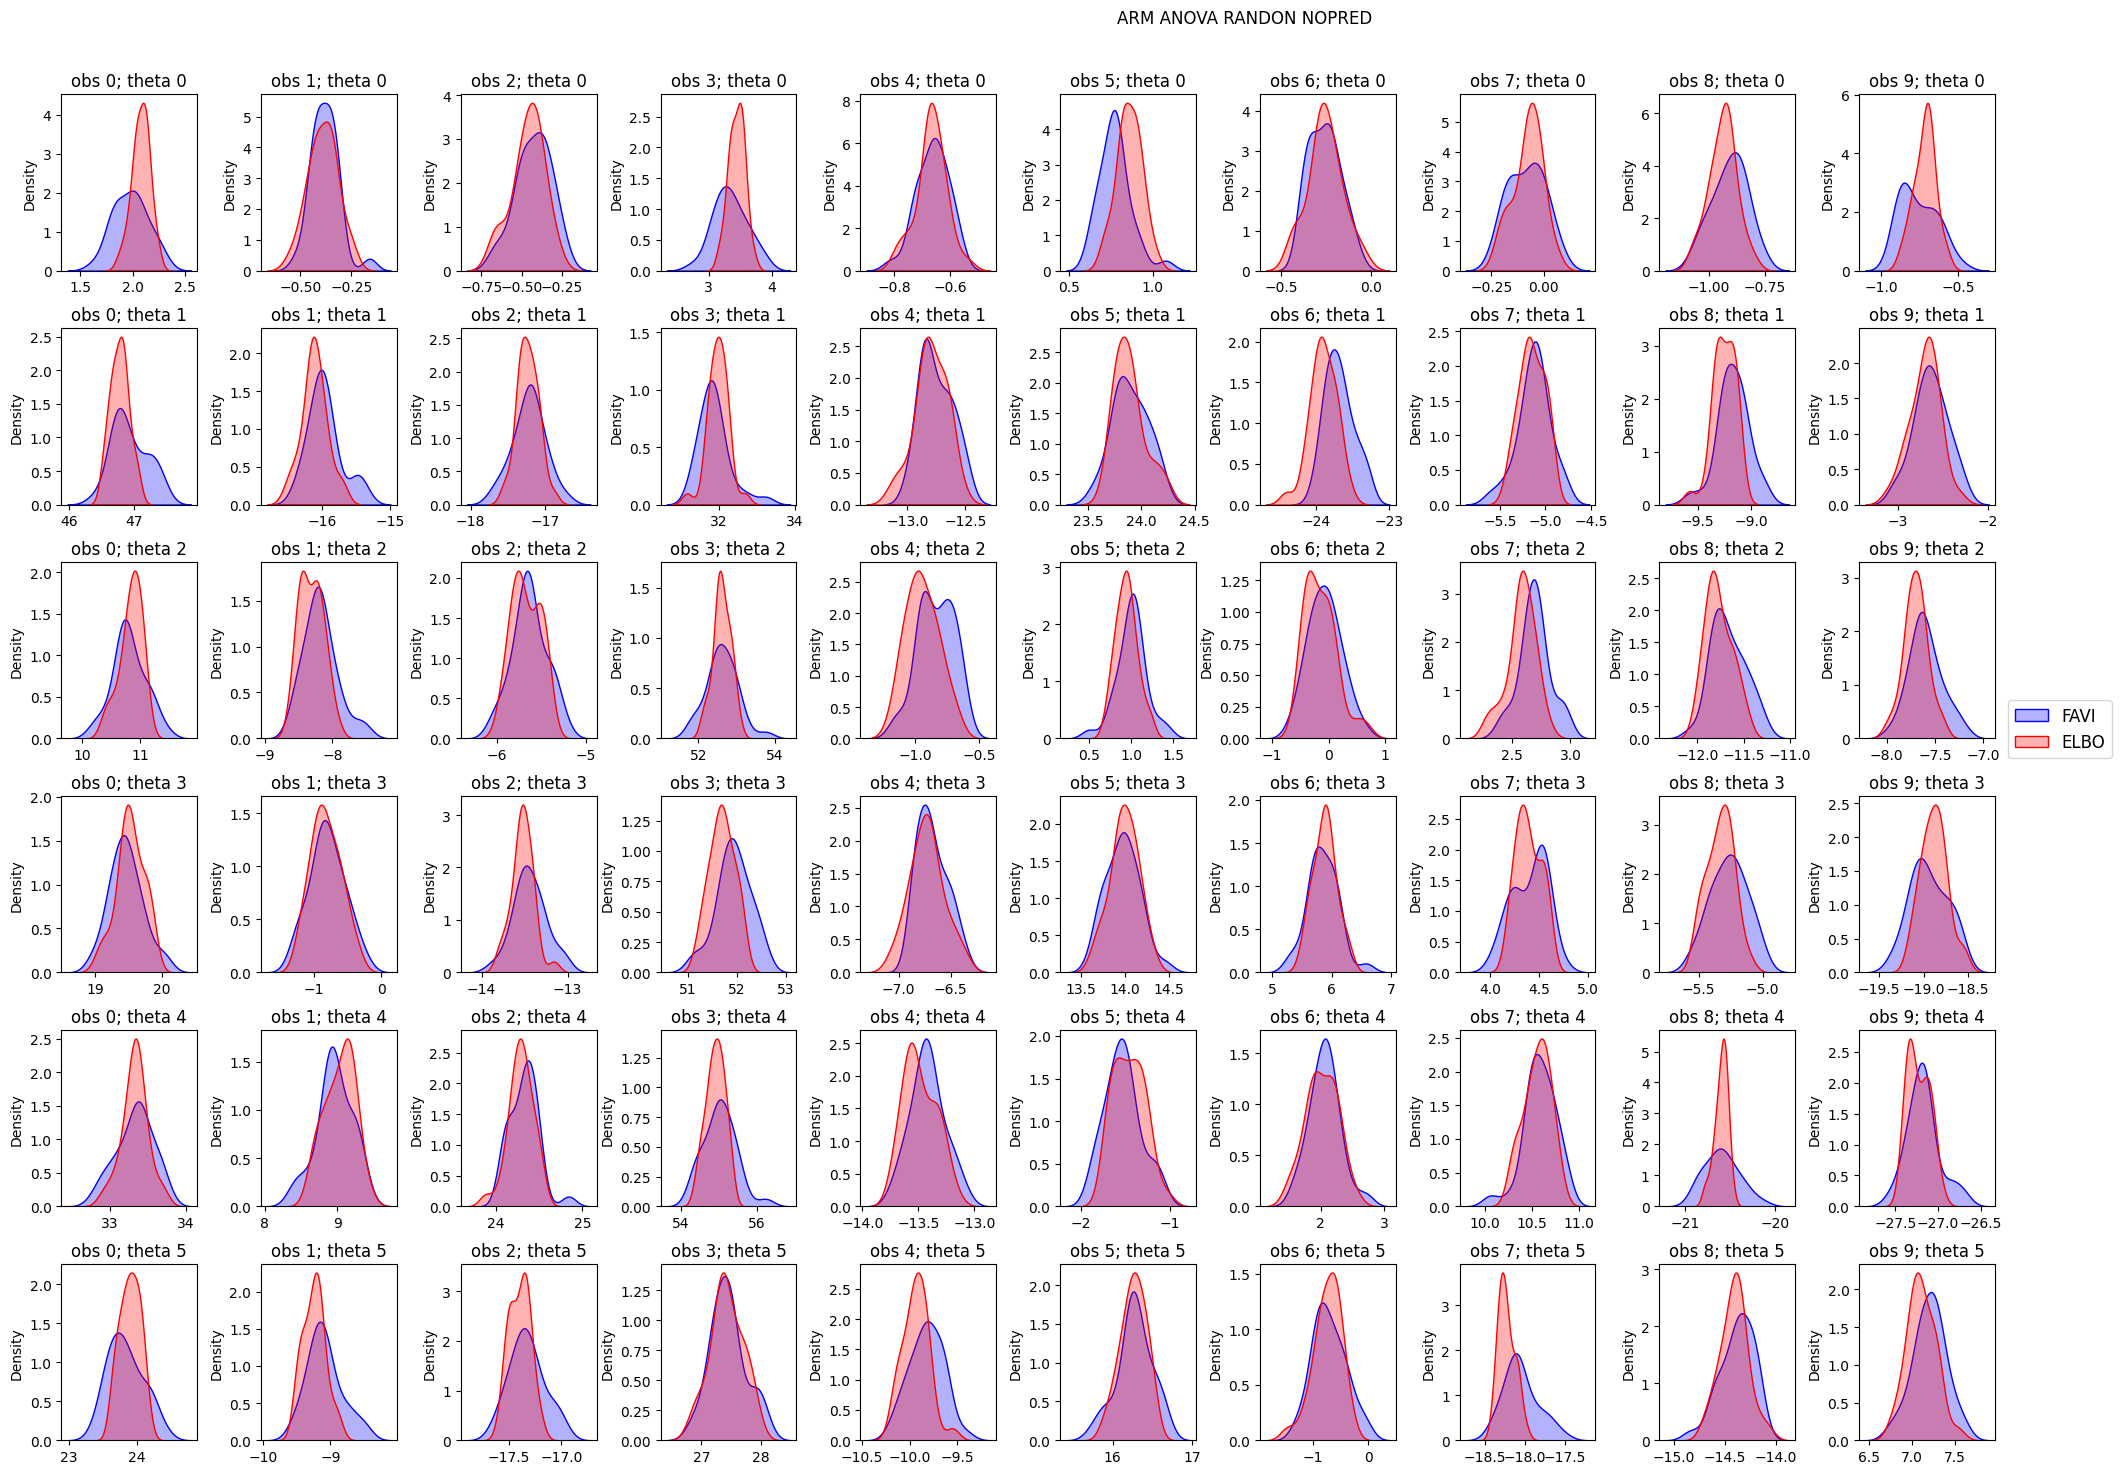

In [6]:
plot_data("/data/scratch/pduan/gcvi_output/pyro_arm_anova_randon_nopred_30.pt")

In [7]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [8]:
task_list = [t for t in sbibm.get_available_tasks() if t not in ["sir", "lotka_volterra"]]

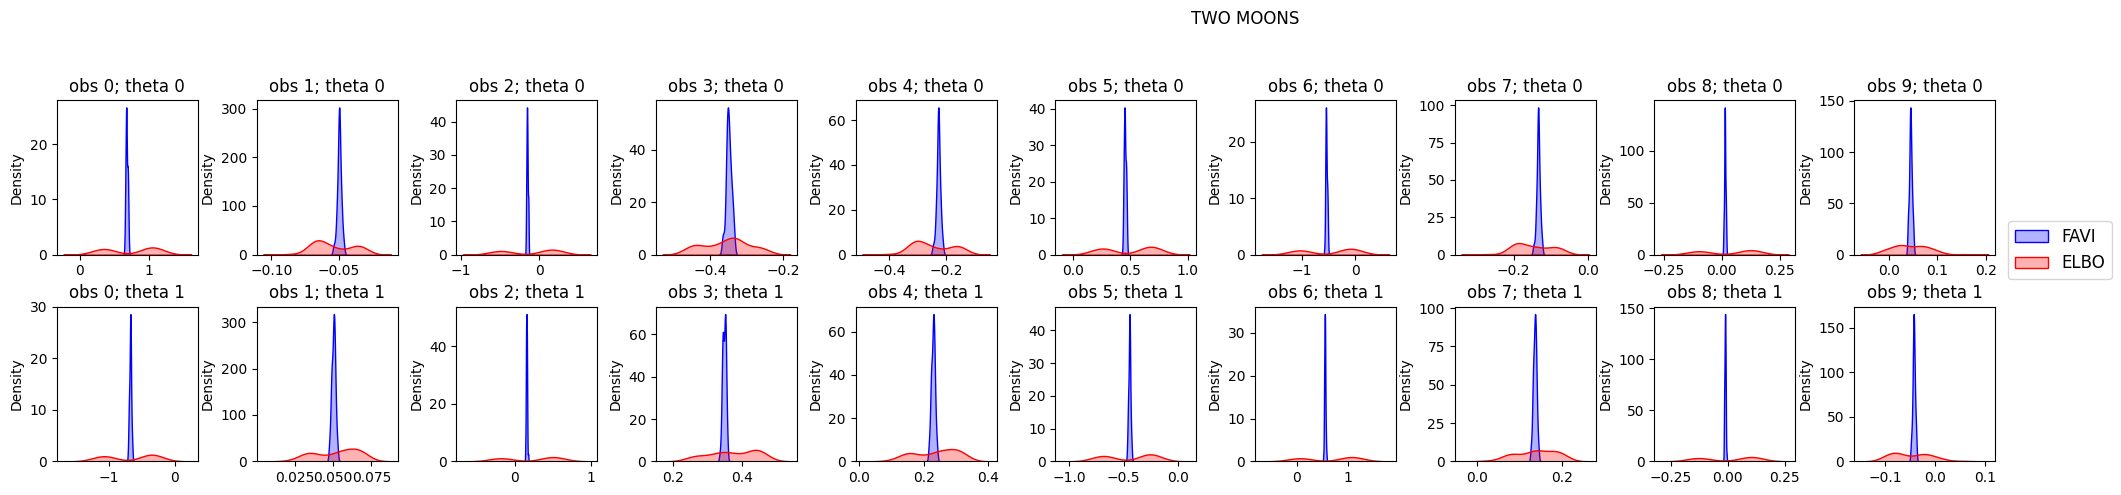

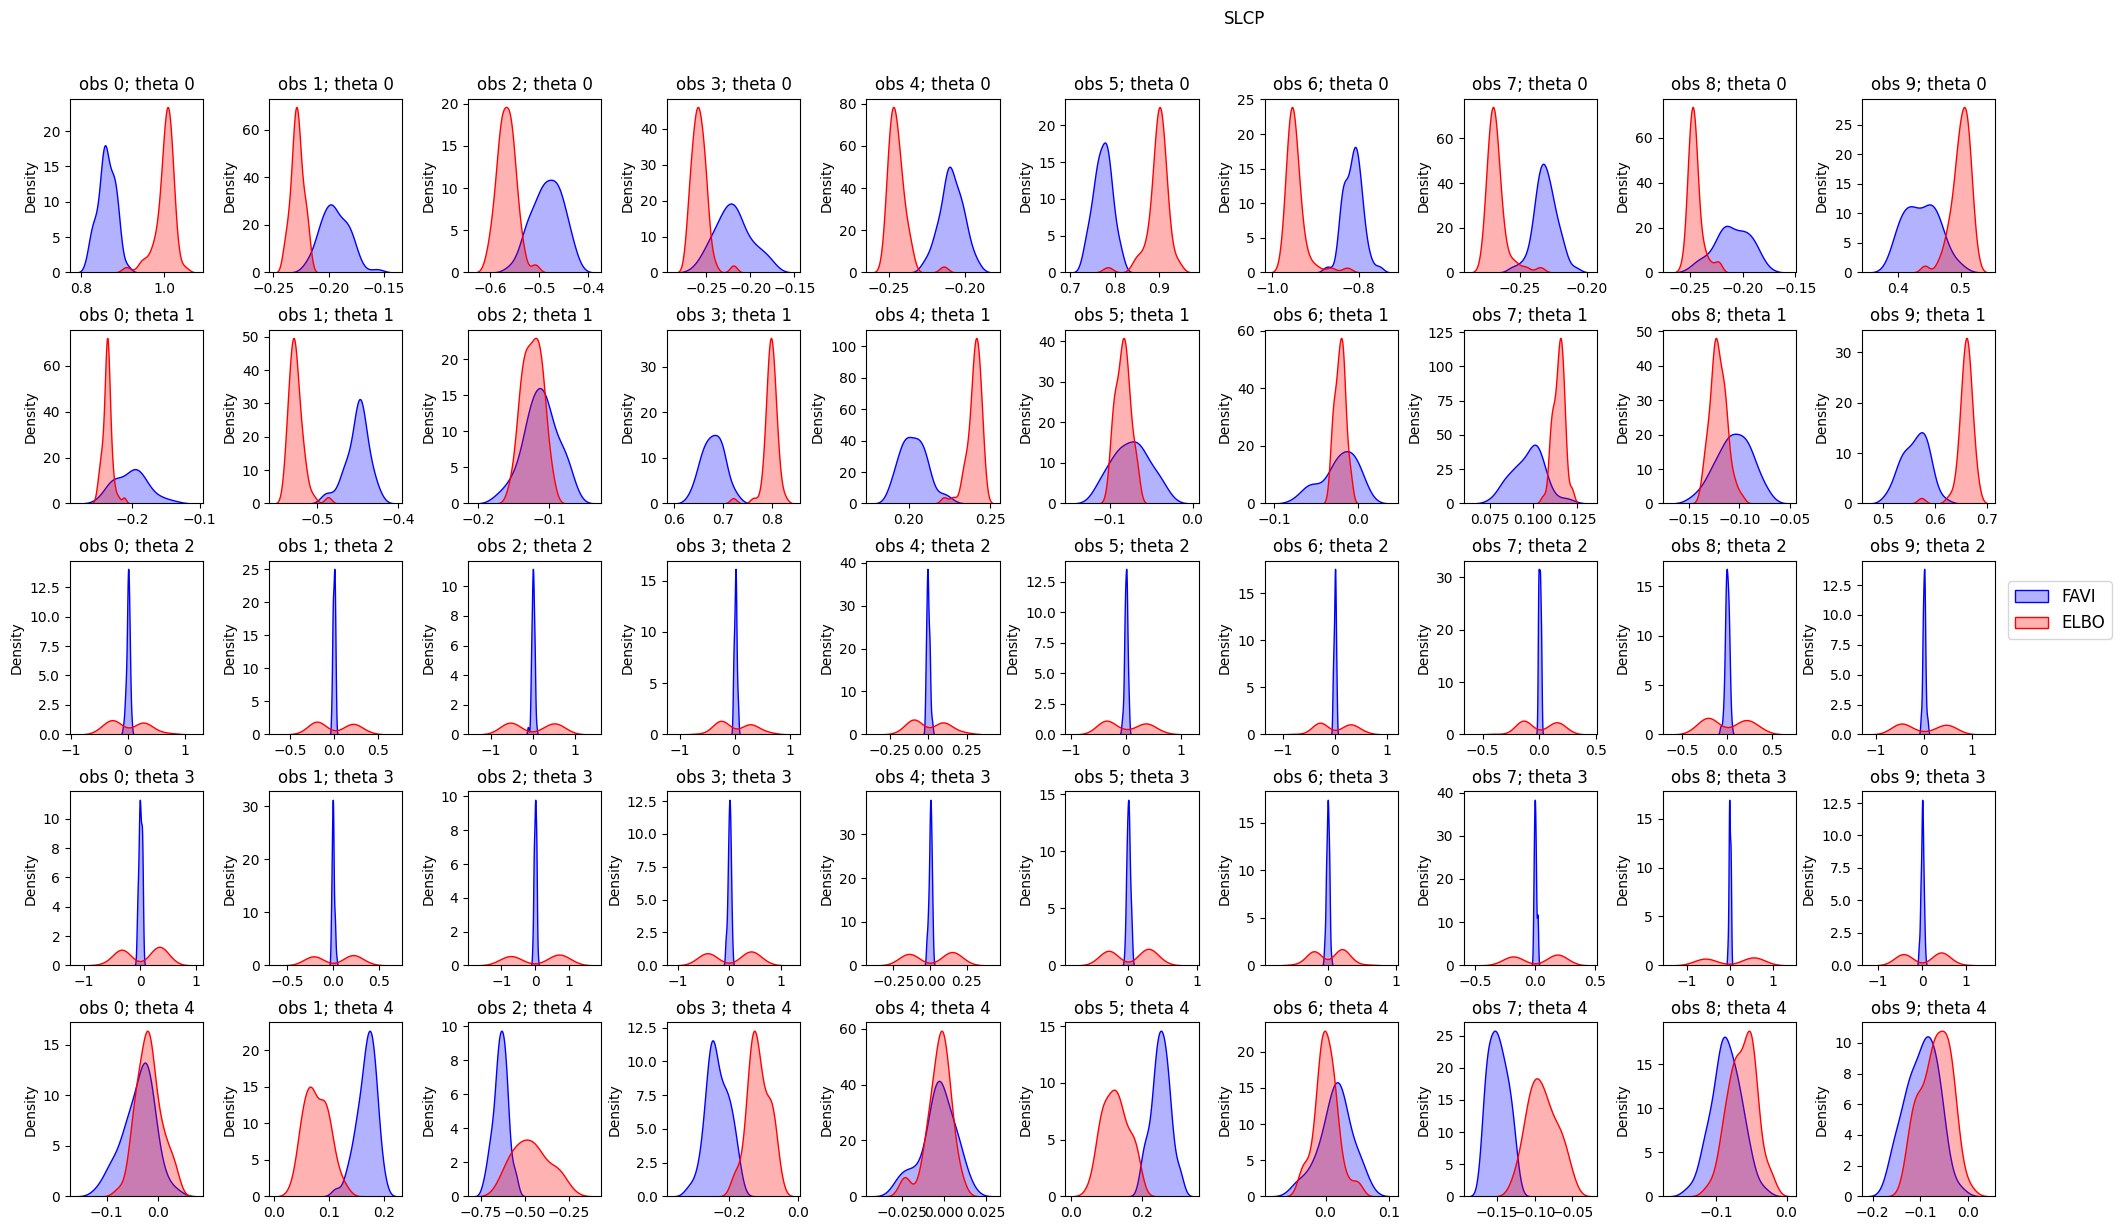

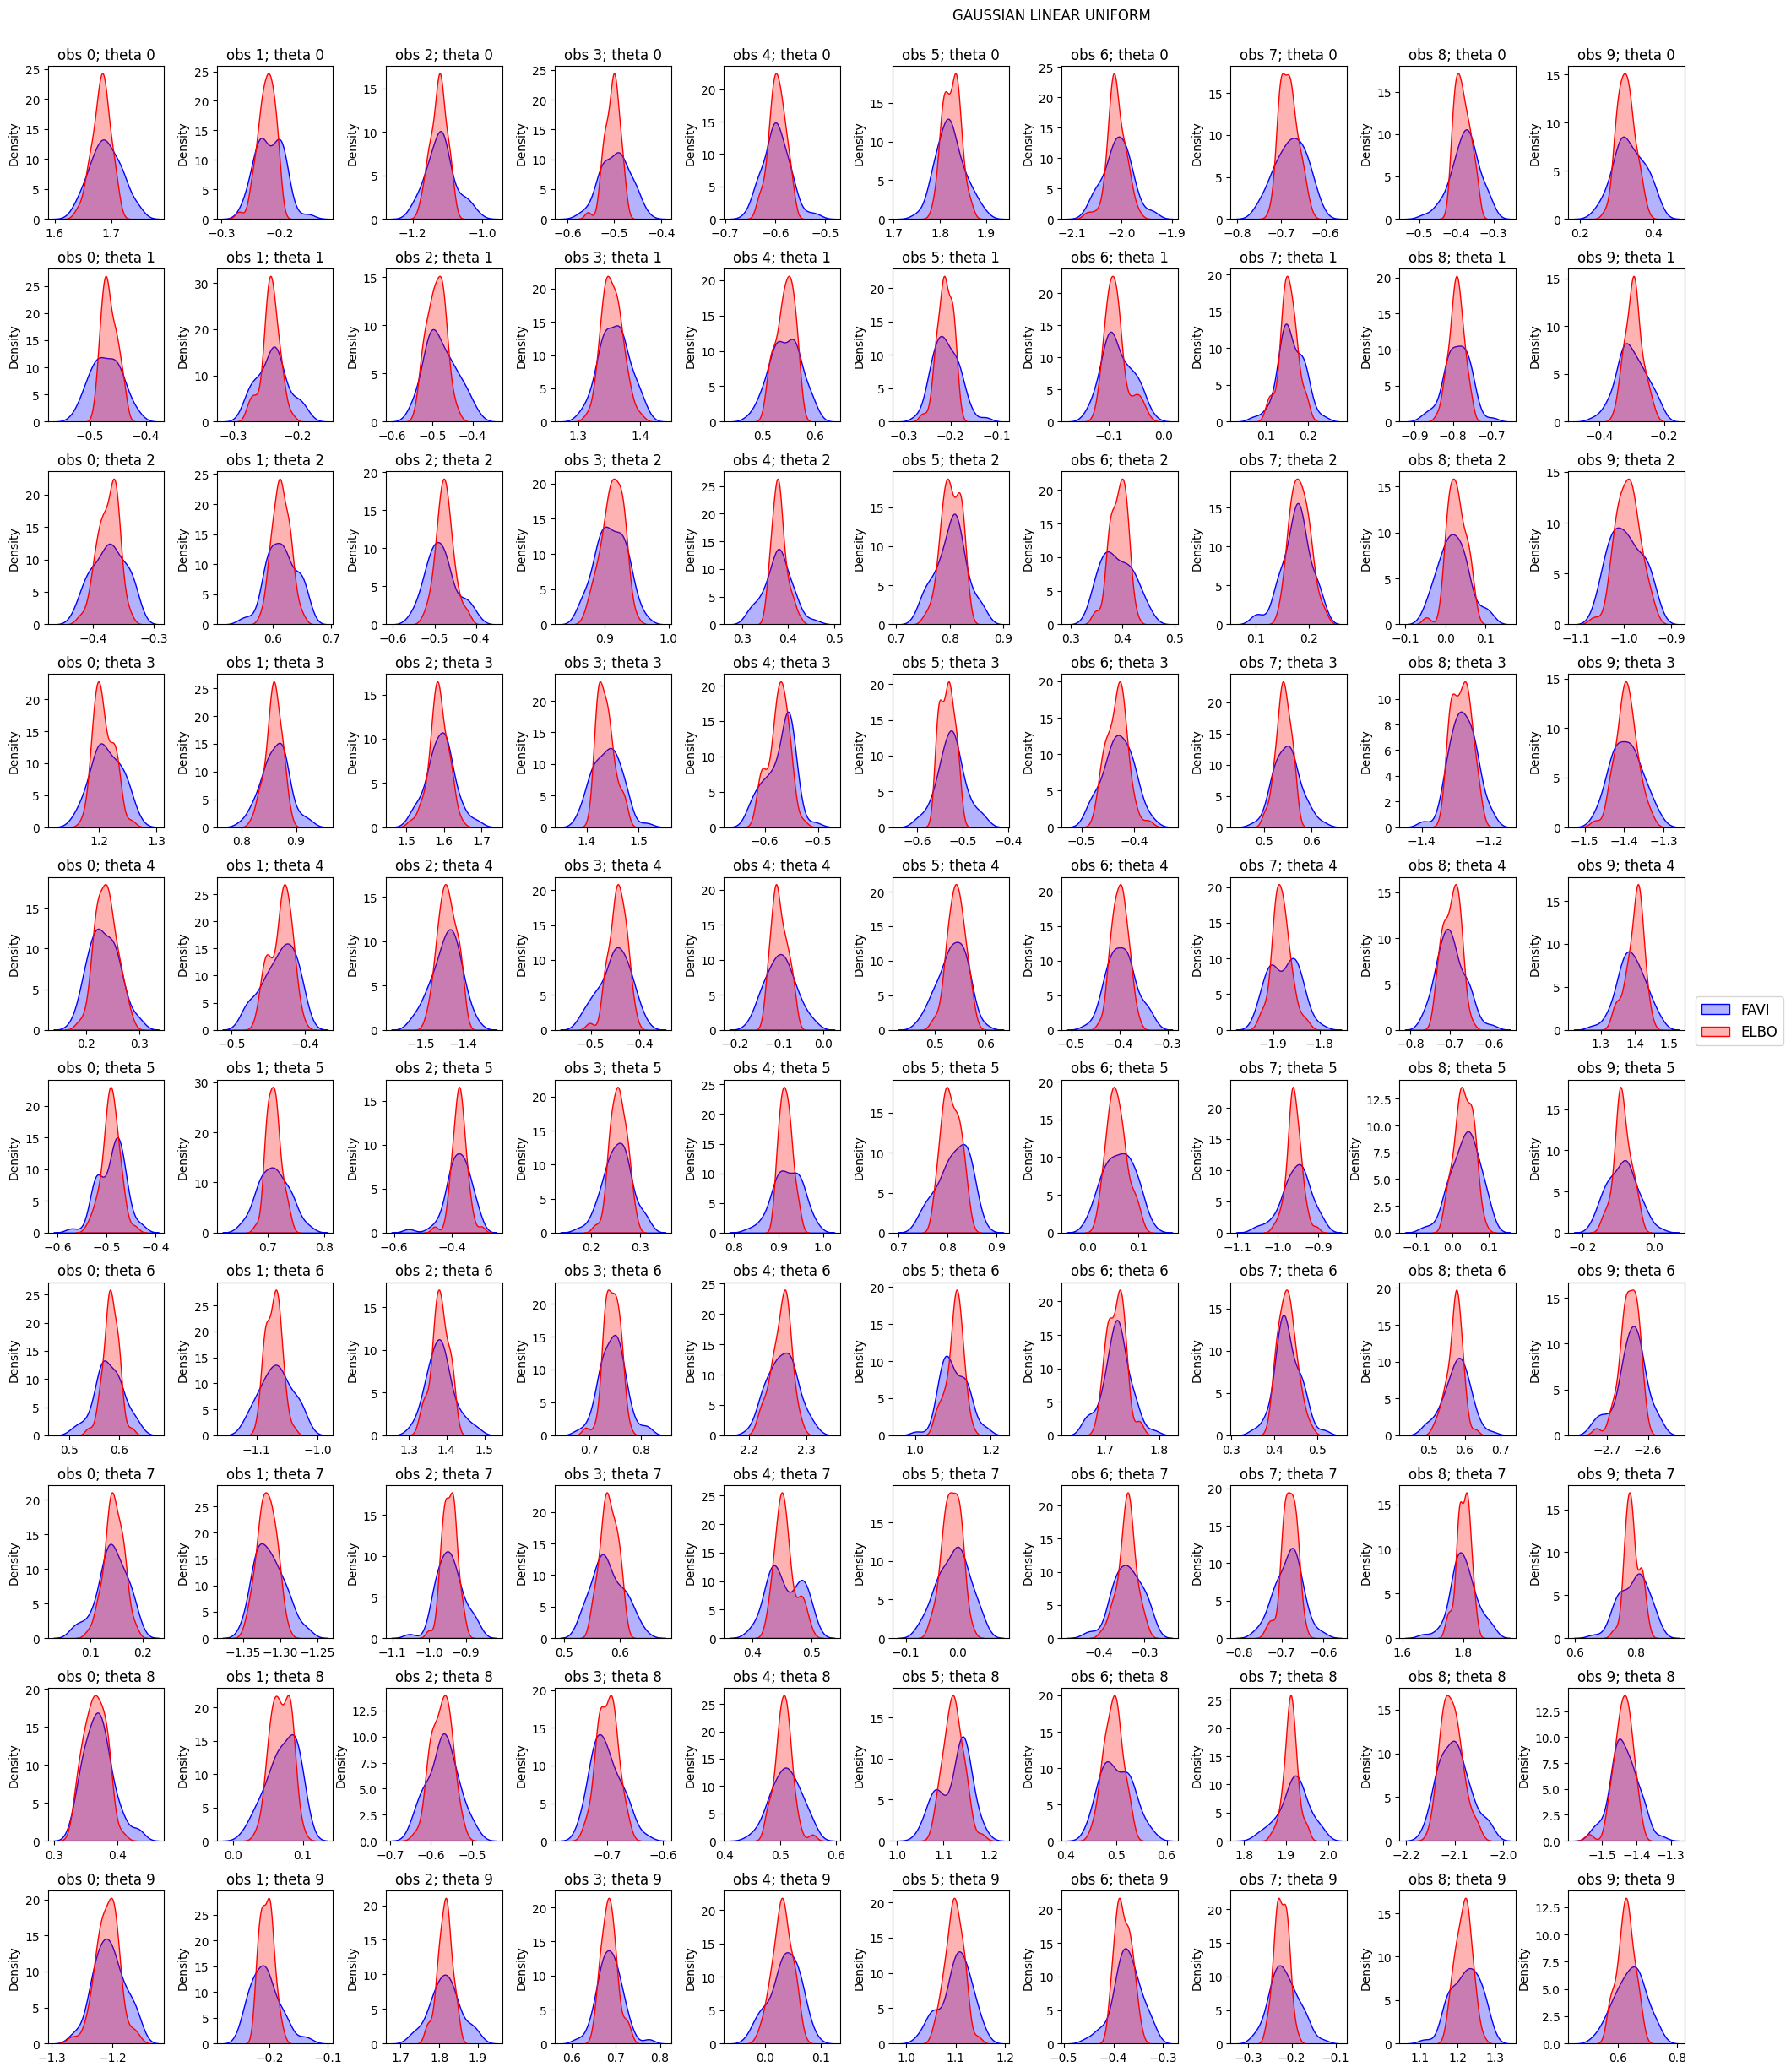

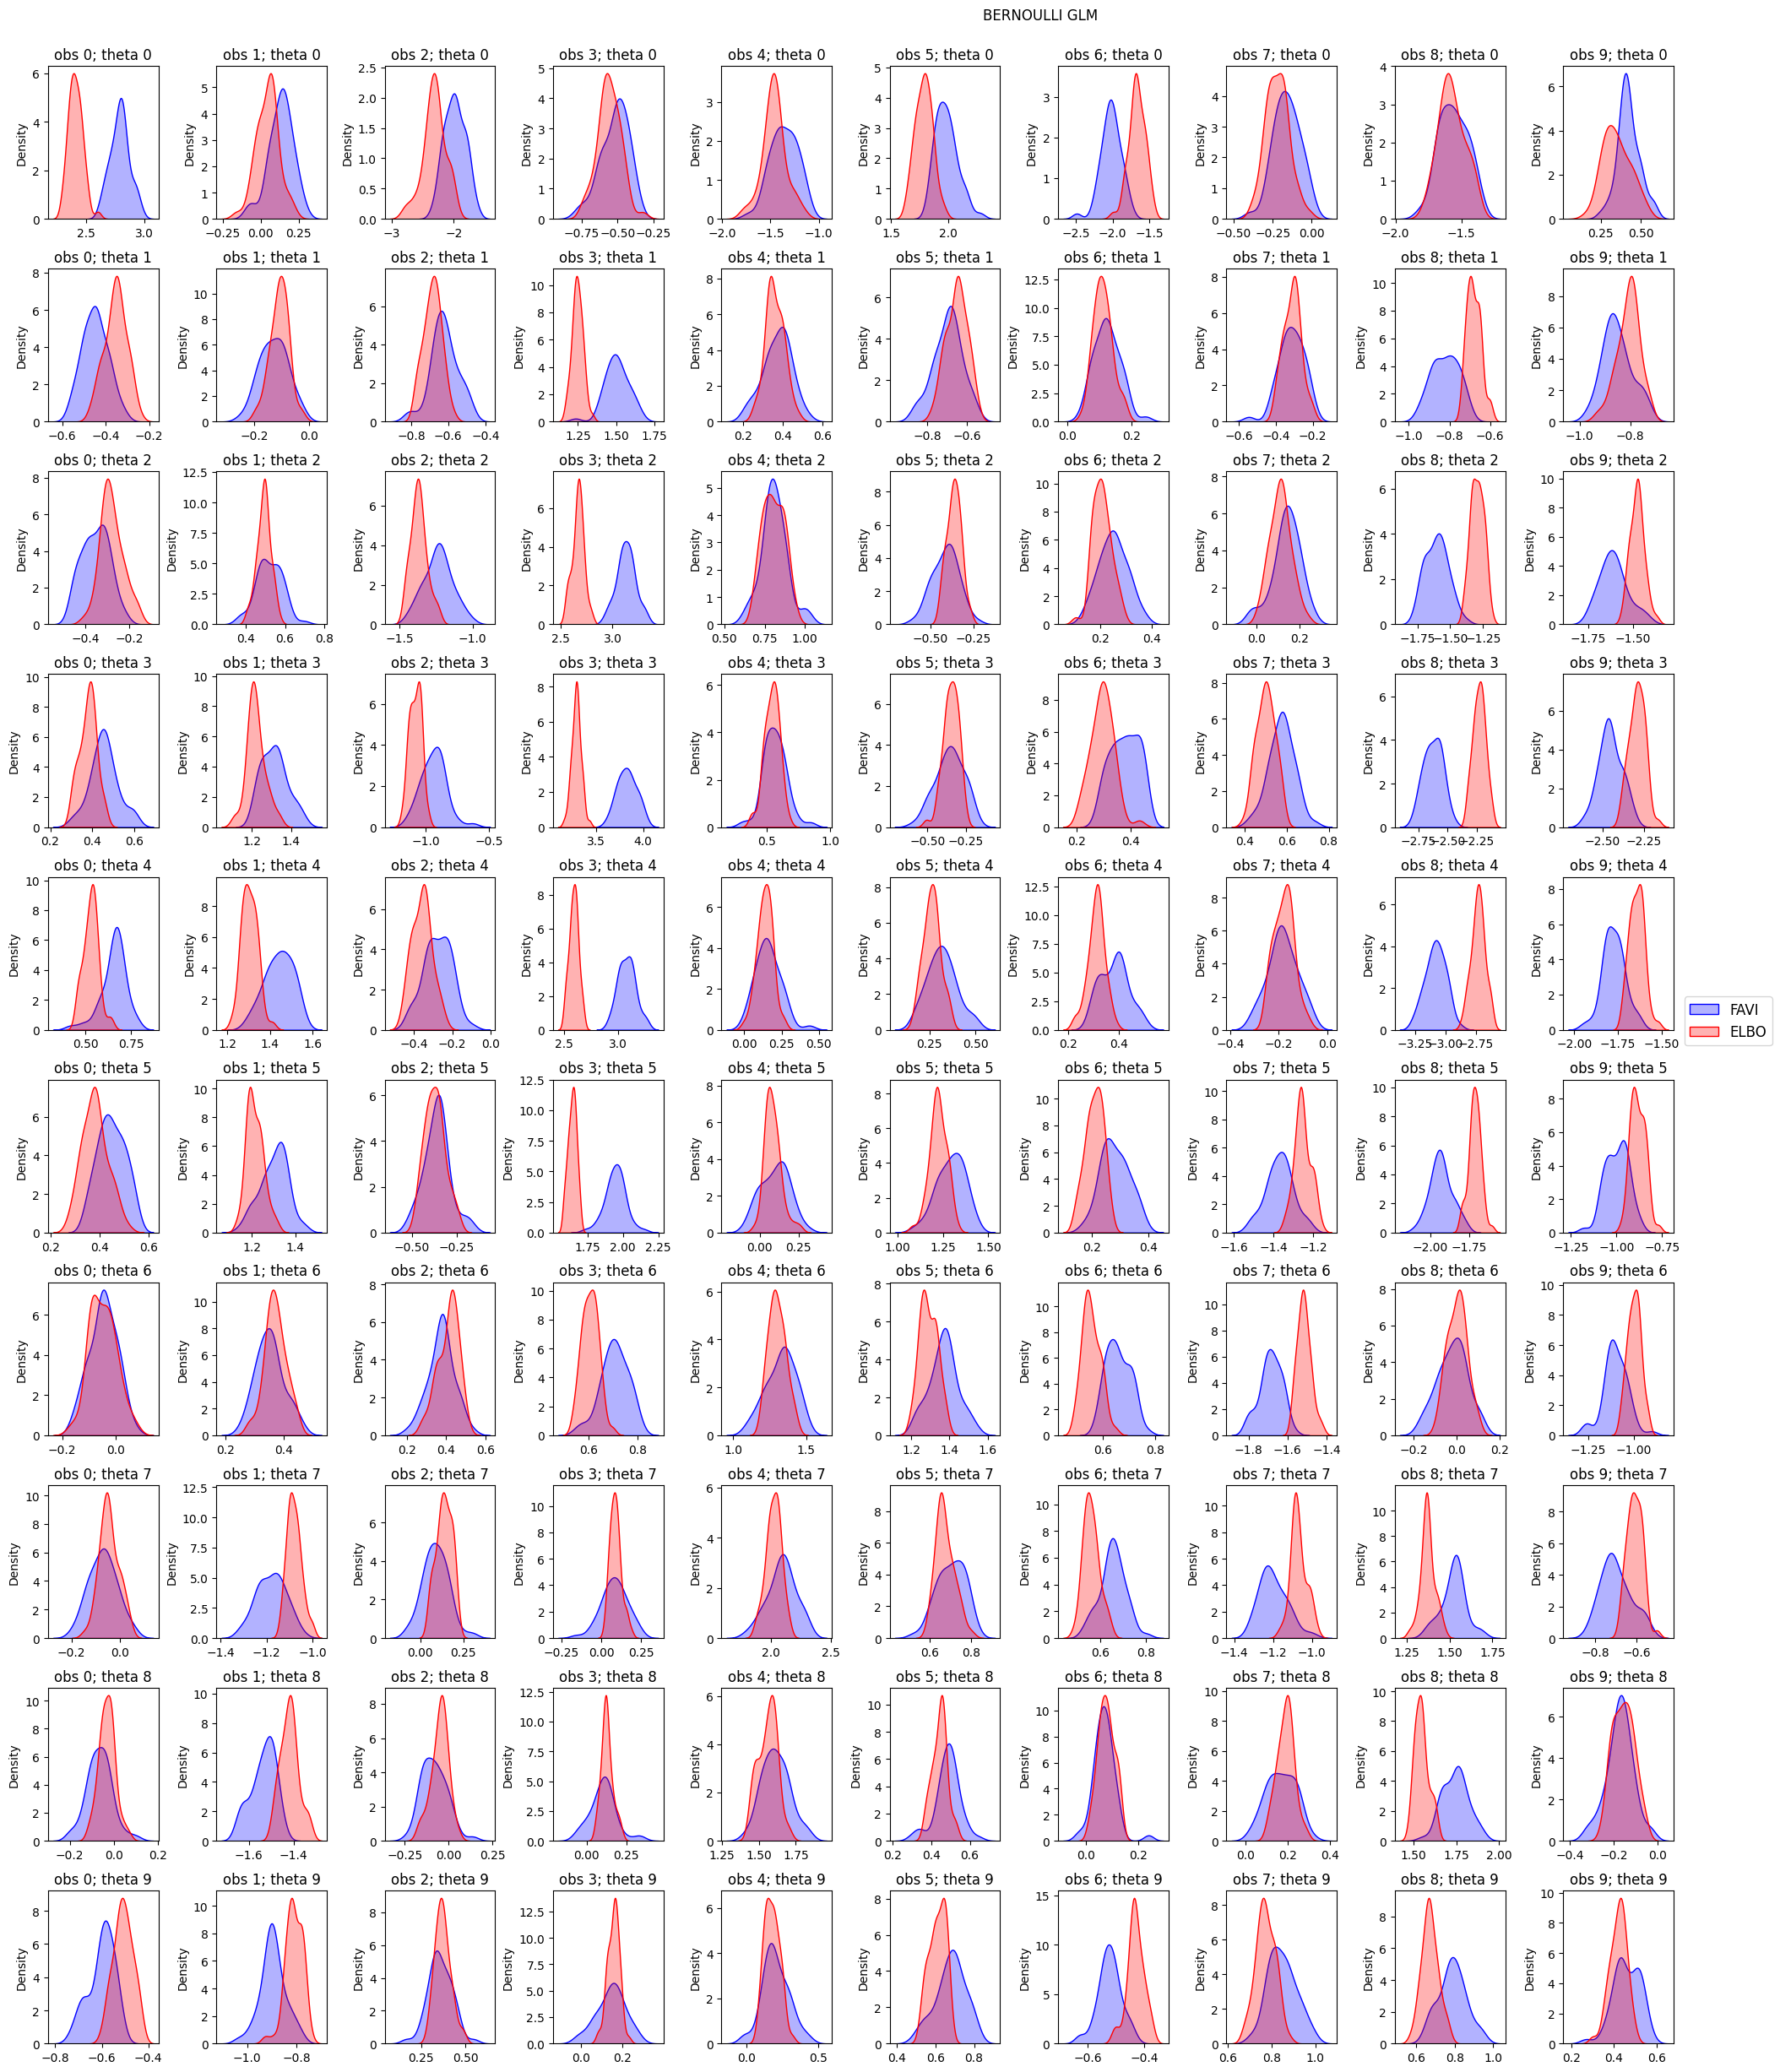

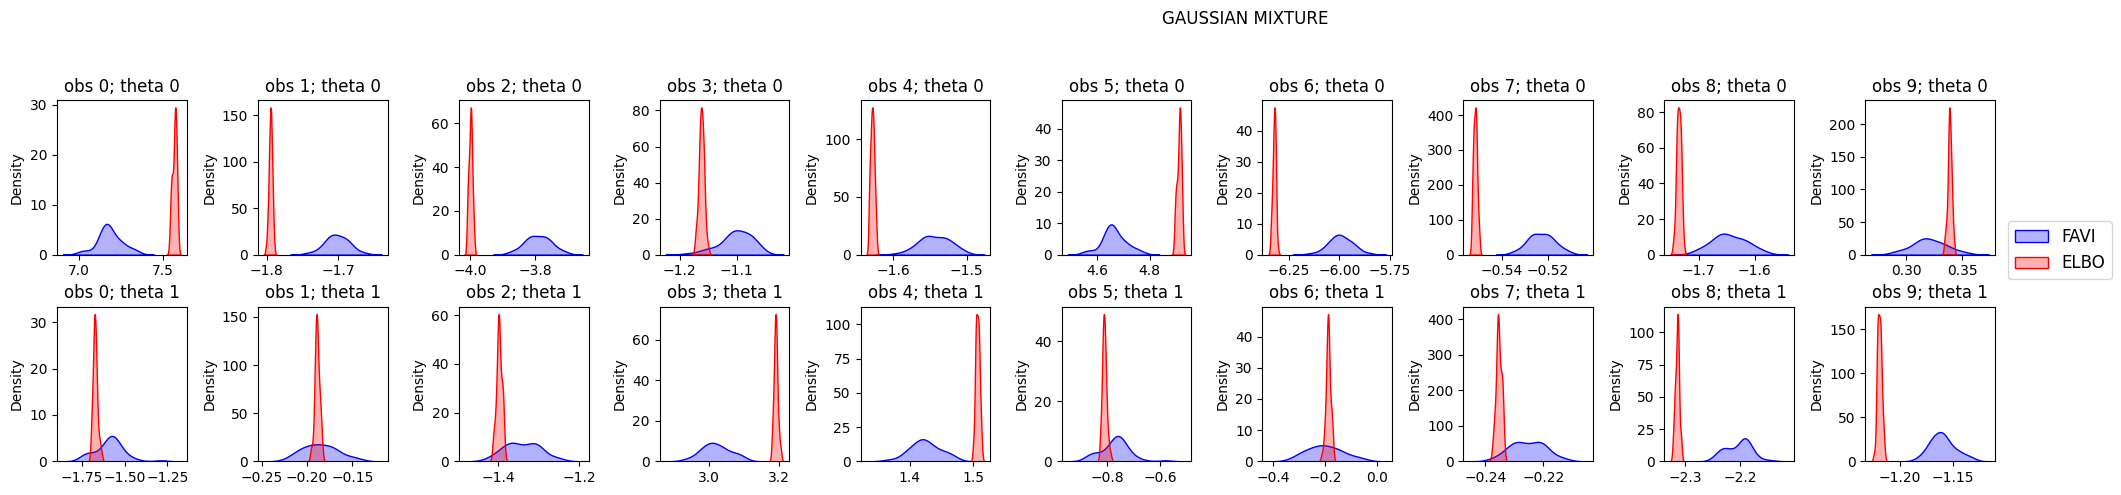

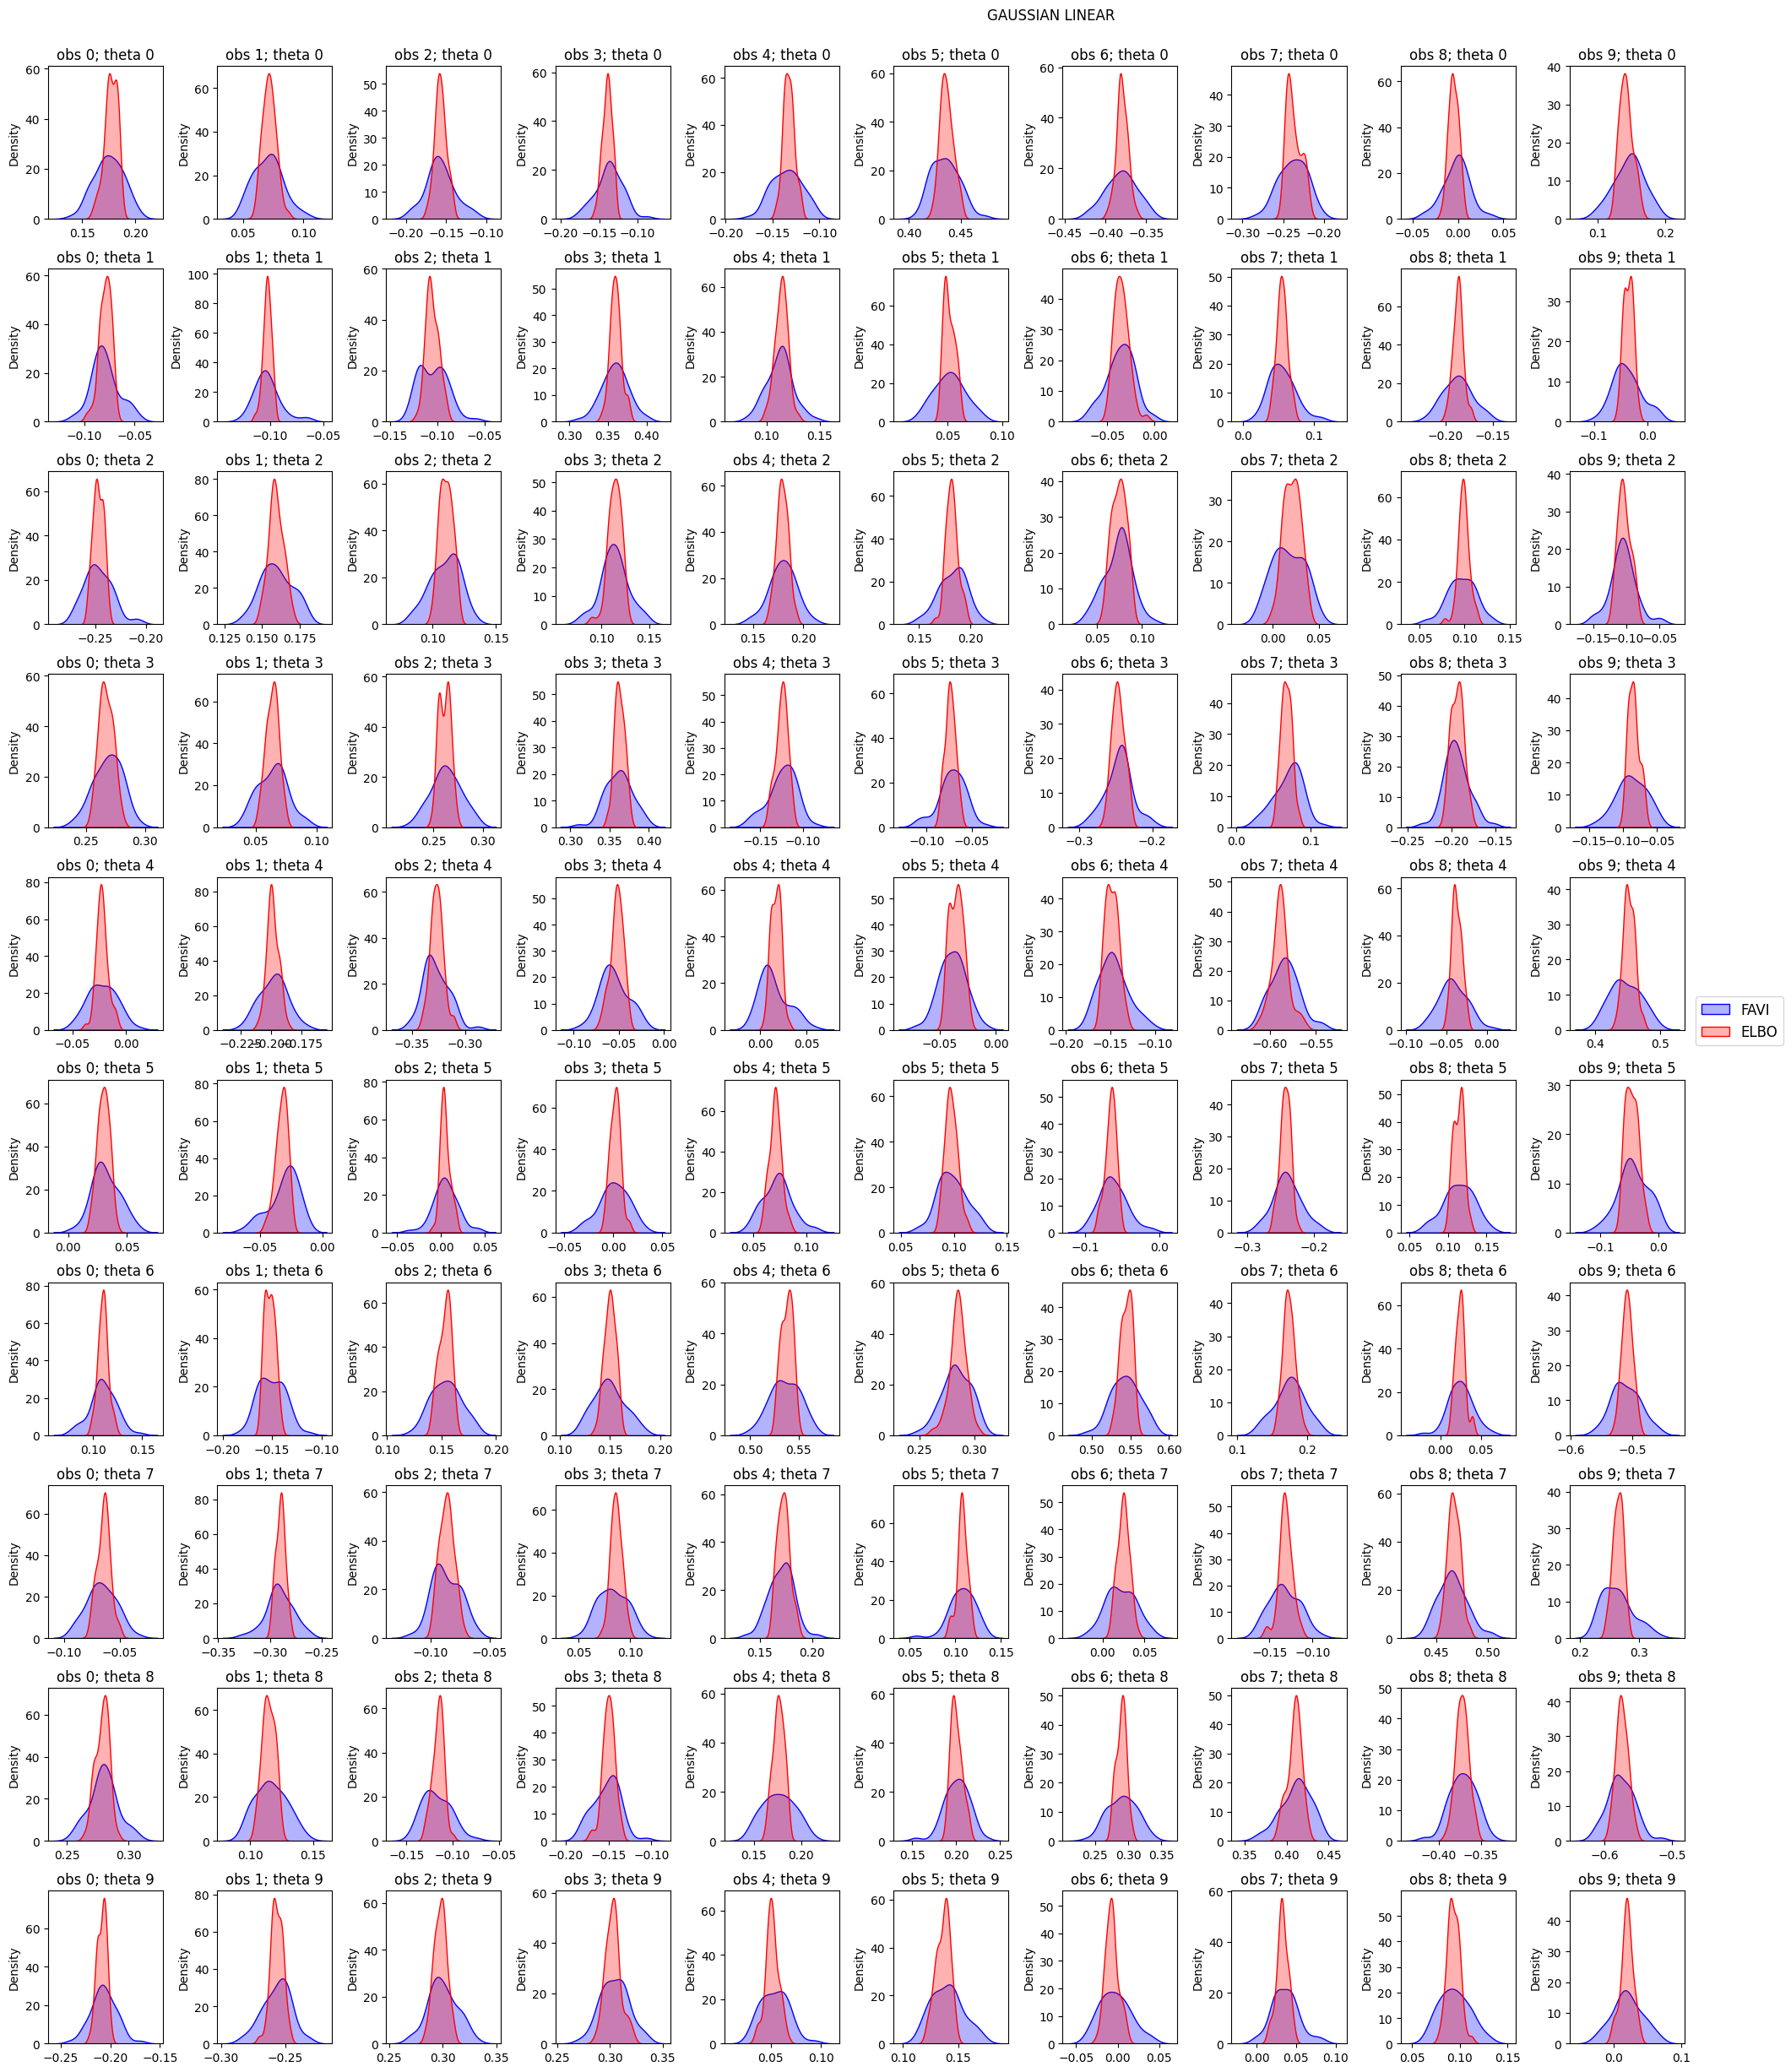

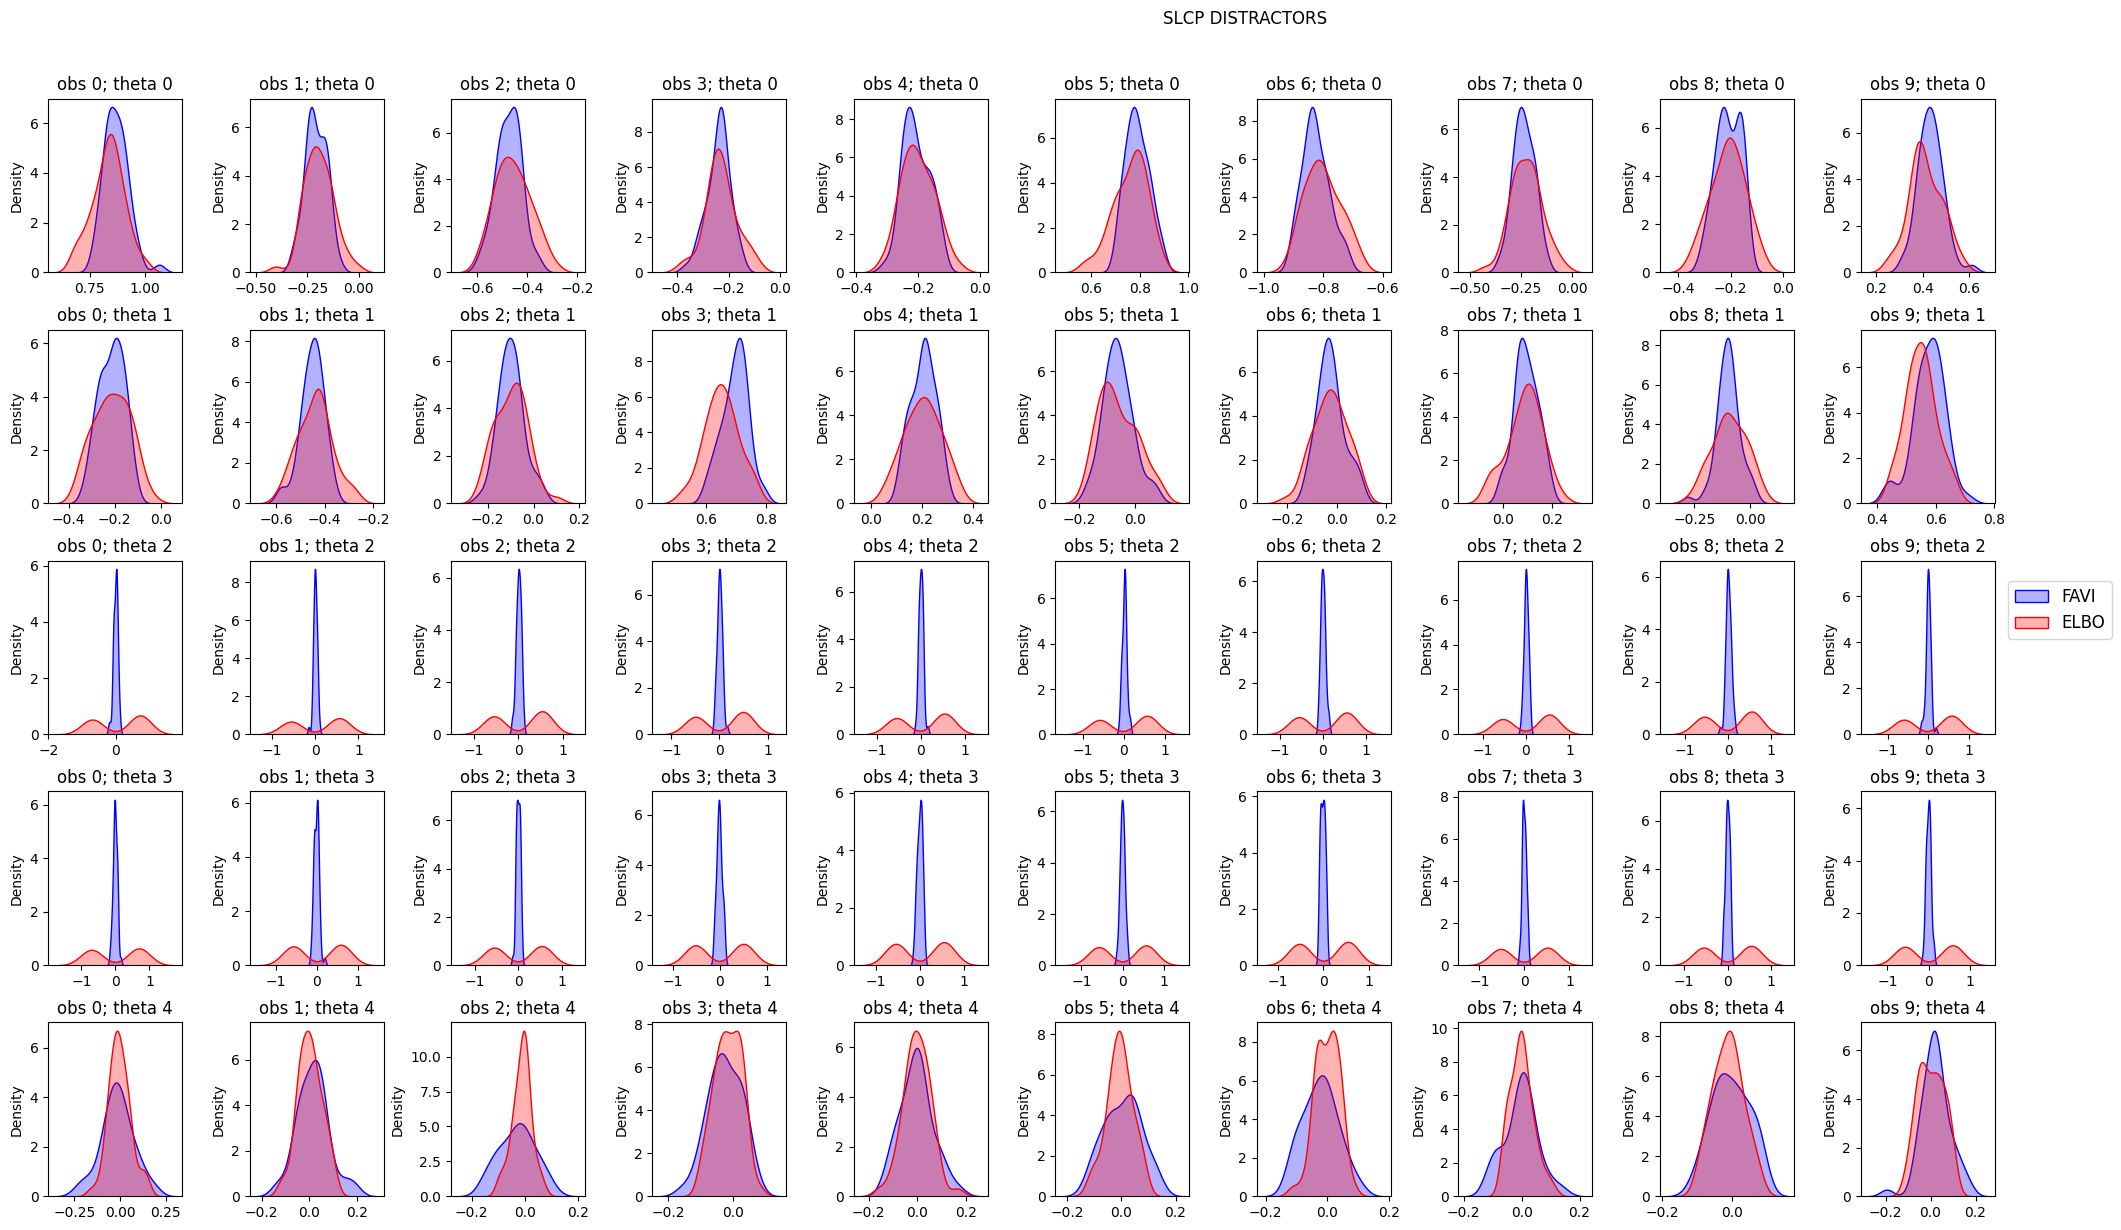

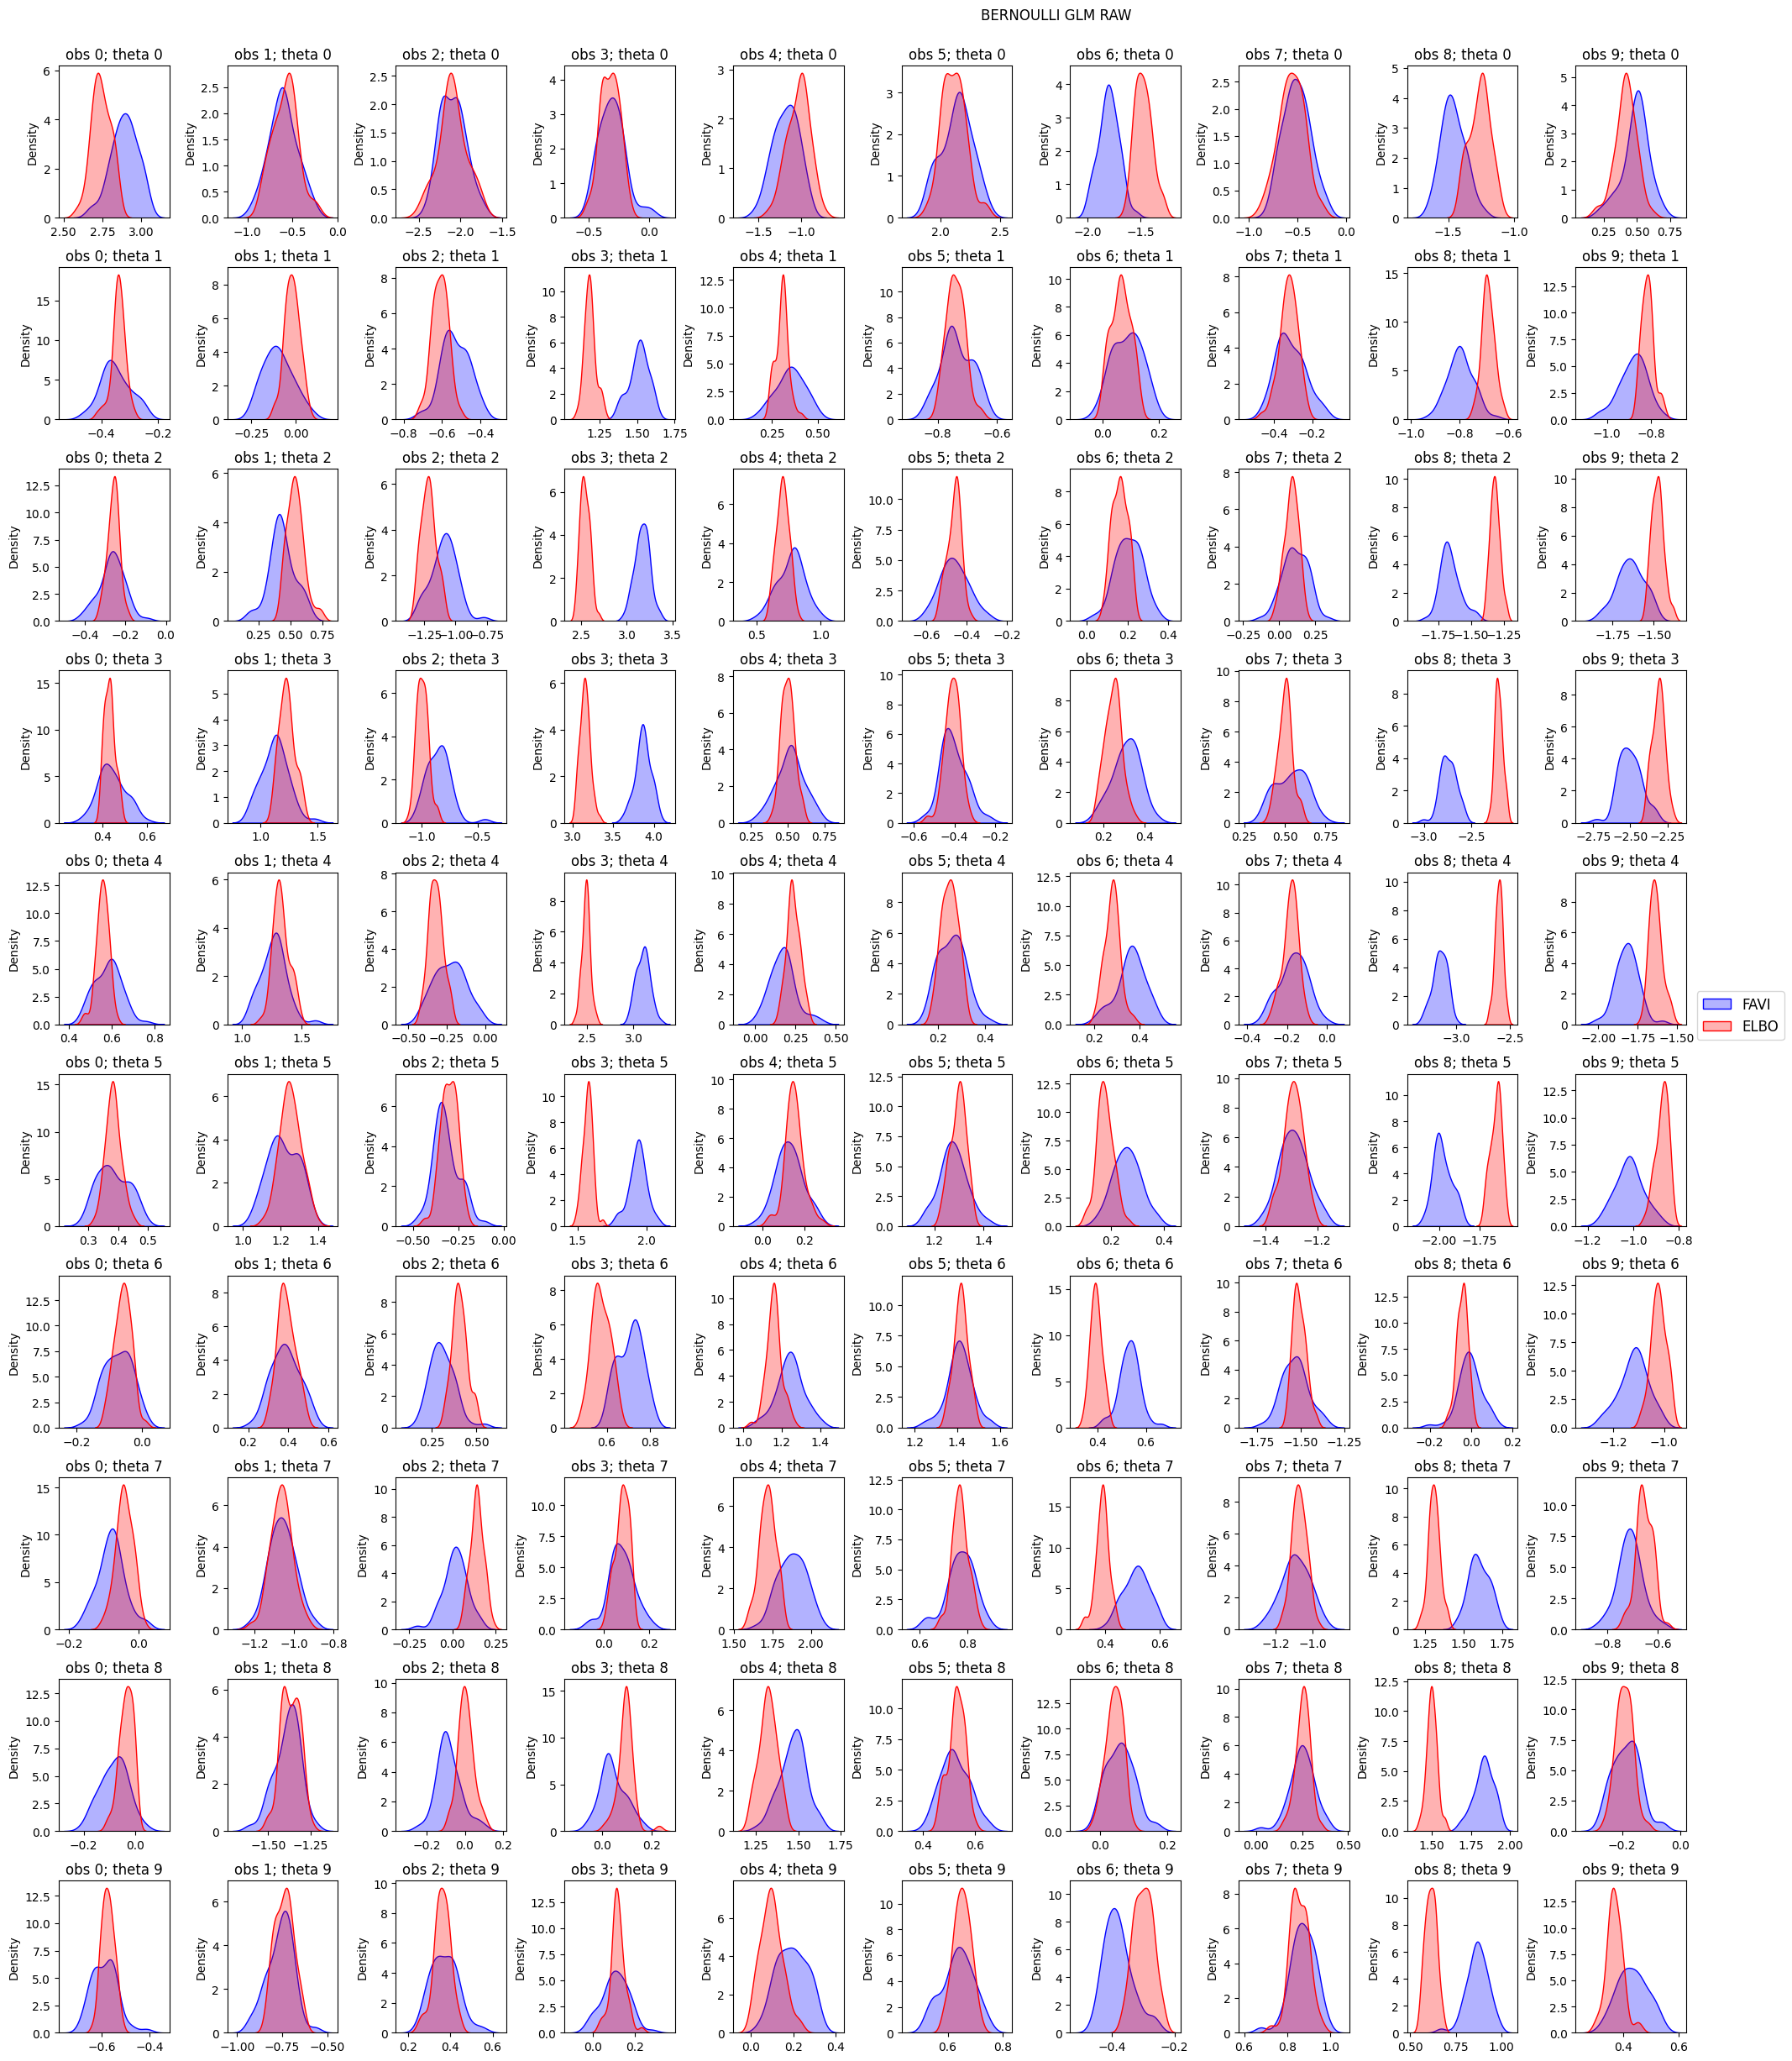

In [9]:
for t in task_list:
    plot_data(f"/data/scratch/pduan/gcvi_output/pyro_{t}_50.pt")